In [1]:
import jax
import jax.numpy as jnp
from tensorflow_probability.substrates import jax as tfp

import numpy as np
from numpy import linalg
from matplotlib import pyplot as plt

import seaborn as sns

## Define log-pdfs

In [2]:
tfd = tfp.distributions

### Create a mixture of three Bivariate Gaussians:

gm = tfd.MixtureSameFamily(
  mixture_distribution=tfd.Categorical(
      probs=jnp.array([0.2, 0.2, 0.2, 0.2])),
  components_distribution=tfd.MultivariateNormalDiag(
      loc=jnp.array([[-1., 1], 
           [1, -1],
           [-1, -1],
           [1, 1]]),  
      scale_identity_multiplier=jnp.array([.2, .2, .2, .2])))

(-2.0, 2.0)

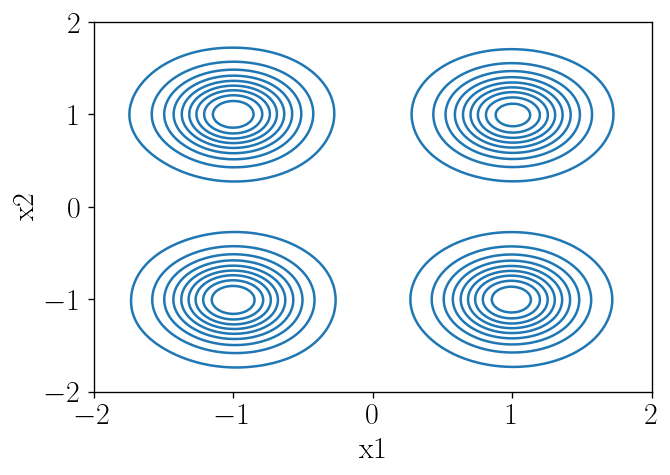

In [3]:
rng_key = jax.random.PRNGKey(0)
samples_truth = gm.sample(10000, seed=rng_key)

samples = {}
samples['x1'] = samples_truth[:, 0]
samples['x2'] = samples_truth[:, 1]

sns.kdeplot(data=samples, x='x1', y='x2')
plt.xlim(-2, 2)
plt.ylim(-2, 2)

In [4]:
@jax.jit
def loglike(x):
    return gm.log_prob(x)
    
def log_prior(x):
    if -2.0 < x[0] < 2.0 and -2.0 < x[0] < 2.0:
        return 0.0
    return -np.inf

def log_probability(x):
    lp = log_prior(x)
    if not np.isfinite(lp):
        return -np.inf
    return np.array(lp + loglike(x))

## `emcee`

In [5]:
import emcee

pos = jnp.array(np.array([0.5, 0.5]) + 1e-3 * np.random.randn(16, 2))
nwalkers, ndim = pos.shape

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability
)

sampler.run_mcmc(pos, 10000, progress=True);

100%|███████████████████████████████████| 10000/10000 [00:02<00:00, 4530.77it/s]


(-2.0, 2.0)

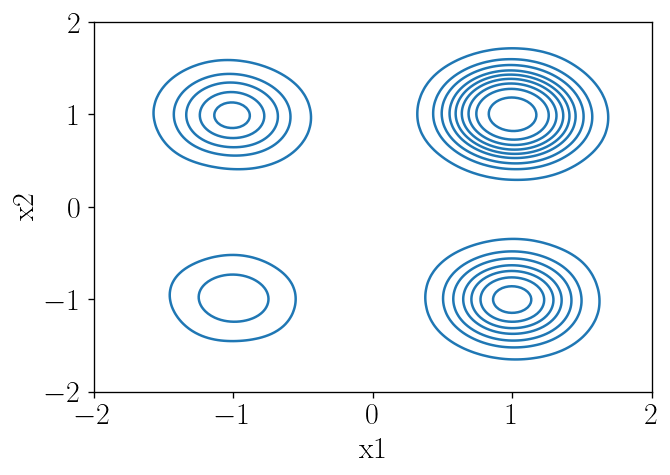

In [6]:
flat_samples = sampler.get_chain(discard=100, thin=5, flat=True)

samples = {}
samples['x1'] = flat_samples[:, 0]
samples['x2'] = flat_samples[:, 1]

sns.kdeplot(data=samples, x='x1', y='x2')
plt.xlim(-2, 2)
plt.ylim(-2, 2)

## `NumPyro`

In [7]:
import jax

import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, HMC, HMCECS, NUTS, Predictive

In [8]:
def model():
    x1 = numpyro.sample("x1", dist.Uniform(-2., 2.))
    x2 = numpyro.sample("x2", dist.Uniform(-2., 2.))
    return numpyro.factor('log-likelihood', loglike(jnp.array([x1, x2])))

In [9]:
kernel = NUTS(model)
num_samples = 10000
num_chains = 8
mcmc = MCMC(kernel, num_warmup=1000, num_samples=num_samples, num_chains=num_chains, chain_method='vectorized')
rng_key = jax.random.PRNGKey(0)
mcmc.run(rng_key)

sample: 100%|███████████████████████████| 11000/11000 [00:07<00:00, 1449.89it/s]


(-2.0, 2.0)

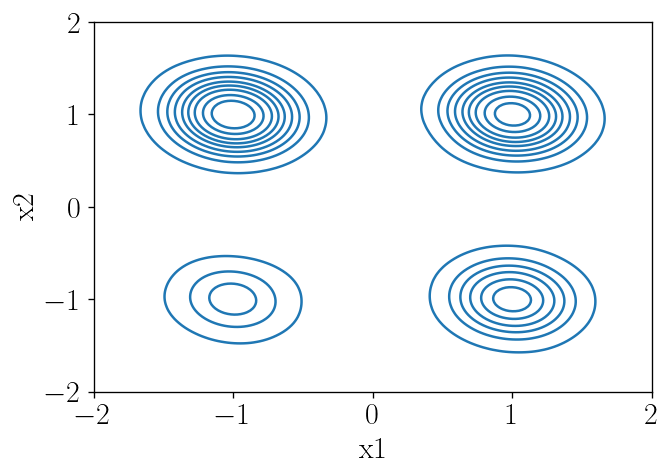

In [16]:
import seaborn as sns
sns.kdeplot(data=mcmc.get_samples(), x='x1', y='x2')
plt.xlim(-2, 2)
plt.ylim(-2, 2)

In [17]:
from numpyro.infer import SVI, Predictive, Trace_ELBO, autoguide
from numpyro import optim
import optax

In [18]:
guide = autoguide.AutoBNAFNormal(model, num_flows=4, hidden_factors=[64, 64])

In [19]:
lr=1e-3
optimizer = optim.optax_to_numpyro(optax.chain(optax.clip(1.), optax.adamw(lr)))

svi = SVI(model, guide, optimizer, Trace_ELBO(num_particles=2))
rng_key = jax.random.PRNGKey(0)
svi_results = svi.run(rng_key, 20000)

100%|█| 20000/20000 [00:51<00:00, 384.78it/s, init loss: 32.4957, avg. loss [190


In [20]:
posterior = guide.sample_posterior(rng_key=rng_key, params=svi_results.params, sample_shape=(10000,))

(-2.0, 2.0)

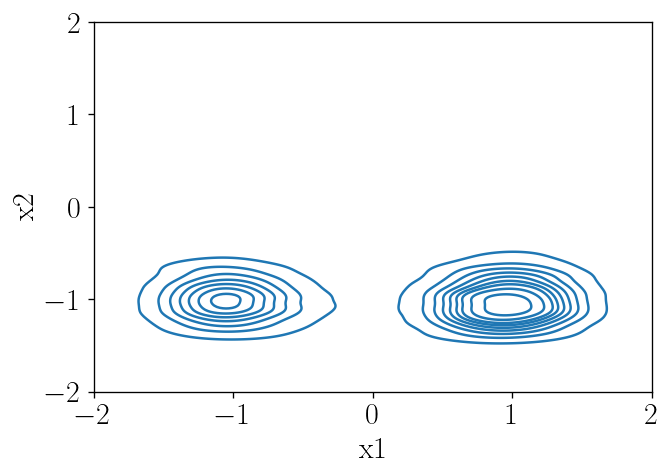

In [21]:
import seaborn as sns
sns.kdeplot(data=posterior, x='x1', y='x2')
plt.xlim(-2, 2)
plt.ylim(-2, 2)

In [22]:
from numpyro.infer.reparam import NeuTraReparam

In [23]:
neutra = NeuTraReparam(guide, svi_results.params)
neutra_model = neutra.reparam(model)

In [24]:
kernel = NUTS(neutra_model)
num_samples = 10000
num_chains = 1
mcmc = MCMC(kernel, num_warmup=1000, num_samples=num_samples, num_chains=num_chains, chain_method='vectorized')
rng_key = jax.random.PRNGKey(0)
mcmc.run(rng_key)

sample: 100%|█| 11000/11000 [00:22<00:00, 498.60it/s, 7 steps of size 6.16e-02. 


(-2.0, 2.0)

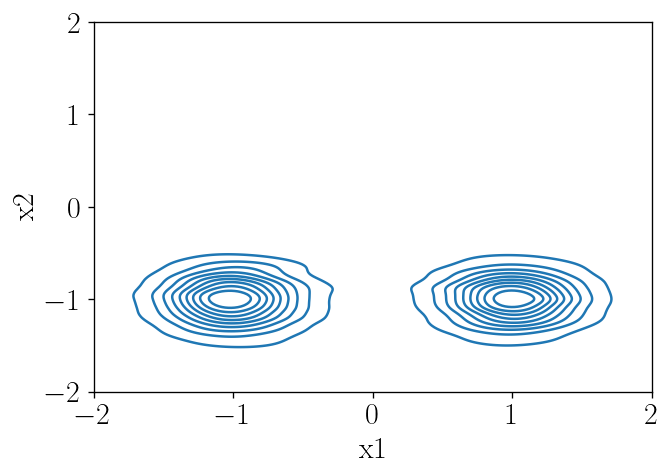

In [25]:
neutra_samples = mcmc.get_samples(group_by_chain=True)["auto_shared_latent"]
samples = neutra.transform_sample(neutra_samples)

samples['x1'] = samples['x1'].flatten()
samples['x2'] = samples['x2'].flatten()

sns.kdeplot(data=samples, x='x1', y='x2')
plt.xlim(-2, 2)
plt.ylim(-2, 2)

In [26]:
from numpyro.contrib.tfp.mcmc import ReplicaExchangeMC

In [27]:
# Geometric decay is a good rule of thumb.
inverse_temperatures = 0.5 ** jnp.arange(4.)

# If everything was Normal, step_size should be ~ sqrt(temperature).
step_size = 5e-2 / jnp.sqrt(inverse_temperatures)[..., None]

def make_kernel_fn(target_log_prob_fn):
    return tfp.mcmc.HamiltonianMonteCarlo(
      target_log_prob_fn=target_log_prob_fn,
      step_size=step_size, num_leapfrog_steps=5)

In [28]:
kernel = ReplicaExchangeMC(model, inverse_temperatures=inverse_temperatures, make_kernel_fn=make_kernel_fn)
num_samples = 10000
num_chains = 1
mcmc = MCMC(kernel, num_warmup=1000, num_samples=num_samples, num_chains=num_chains, chain_method='vectorized')
rng_key = jax.random.PRNGKey(0)
mcmc.run(rng_key)

  0%|                                                 | 0/11000 [00:00<?, ?it/s]/opt/homebrew/Caskroom/miniforge/base/envs/torch-mps/lib/python3.9/site-packages/tensorflow_probability/python/internal/backend/jax/ops.py:282: UserWarning: Explicitly requested dtype int64 requested in astype is not available, and will be truncated to dtype int32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/google/jax#current-gotchas for more.
  return arr.astype(dtype)
/opt/homebrew/Caskroom/miniforge/base/envs/torch-mps/lib/python3.9/site-packages/tensorflow_probability/python/internal/backend/jax/ops.py:389: UserWarning: Explicitly requested dtype <class 'jax.numpy.int64'> requested in astype is not available, and will be truncated to dtype int32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/google/jax#current-gotch

/opt/homebrew/Caskroom/miniforge/base/envs/torch-mps/lib/python3.9/site-packages/seaborn/distributions.py:1185: UserWarning: The following kwargs were not used by contour: 'ls'
  cset = contour_func(


(-2.0, 2.0)

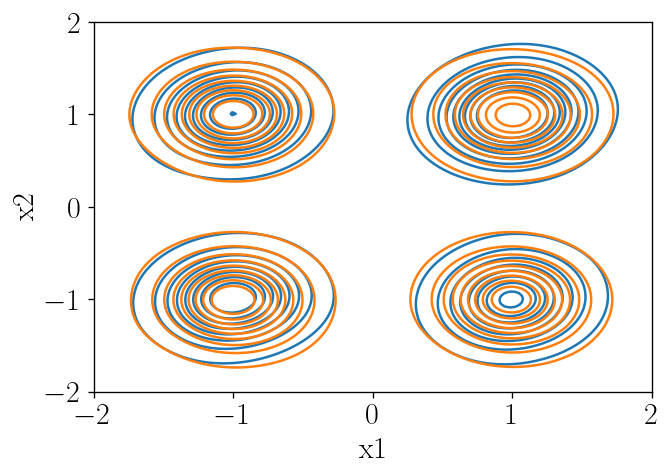

In [29]:
import seaborn as sns
sns.kdeplot(data=mcmc.get_samples(), x='x1', y='x2')

samples_truth = gm.sample(10000, seed=rng_key)

samples['x1'] = samples_truth[:, 0]
samples['x2'] = samples_truth[:, 1]
sns.kdeplot(data=samples, x='x1', y='x2', ls='--')

plt.xlim(-2, 2)
plt.ylim(-2, 2)

In [30]:
# Geometric decay is a good rule of thumb.
inverse_temperatures = 0.5 ** jnp.arange(4.)

# If everything was Normal, step_size should be ~ sqrt(temperature).
step_size = 5e-2 / jnp.sqrt(inverse_temperatures)[..., None]

def make_kernel_fn(target_log_prob_fn):
    
    hmc = tfp.mcmc.HamiltonianMonteCarlo(
    target_log_prob_fn=target_log_prob_fn,
    step_size=step_size, num_leapfrog_steps=3)

    adapted_kernel = tfp.mcmc.SimpleStepSizeAdaptation(
    inner_kernel=hmc,
    num_adaptation_steps=600)

    return adapted_kernel

In [31]:
kernel = ReplicaExchangeMC(neutra_model, inverse_temperatures=inverse_temperatures, make_kernel_fn=make_kernel_fn)
num_samples = 10000
num_chains = 1
mcmc = MCMC(kernel, num_warmup=1000, num_samples=num_samples, num_chains=num_chains, chain_method='vectorized')
rng_key = jax.random.PRNGKey(0)
mcmc.run(rng_key)

  0%|                                                 | 0/11000 [00:00<?, ?it/s]/opt/homebrew/Caskroom/miniforge/base/envs/torch-mps/lib/python3.9/site-packages/tensorflow_probability/python/internal/backend/jax/ops.py:282: UserWarning: Explicitly requested dtype int64 requested in astype is not available, and will be truncated to dtype int32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/google/jax#current-gotchas for more.
  return arr.astype(dtype)
/opt/homebrew/Caskroom/miniforge/base/envs/torch-mps/lib/python3.9/site-packages/tensorflow_probability/python/internal/backend/jax/ops.py:389: UserWarning: Explicitly requested dtype <class 'jax.numpy.int64'> requested in astype is not available, and will be truncated to dtype int32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/google/jax#current-gotch

/opt/homebrew/Caskroom/miniforge/base/envs/torch-mps/lib/python3.9/site-packages/seaborn/distributions.py:1185: UserWarning: The following kwargs were not used by contour: 'ls'
  cset = contour_func(


(-2.0, 2.0)

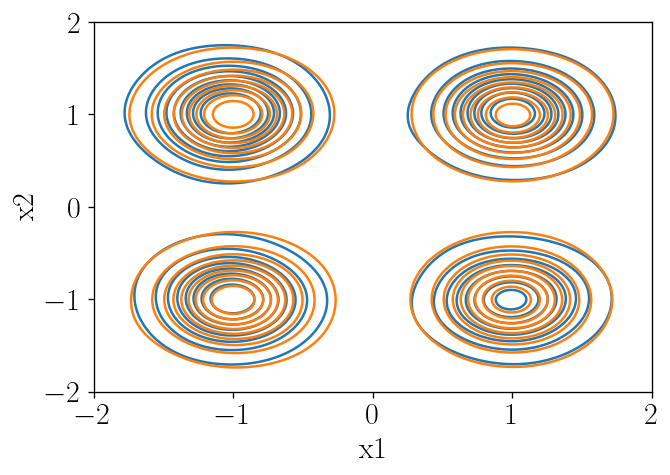

In [32]:
neutra_samples = mcmc.get_samples(group_by_chain=True)["auto_shared_latent"]
samples = neutra.transform_sample(neutra_samples)

samples['x1'] = samples['x1'].flatten()
samples['x2'] = samples['x2'].flatten()
sns.kdeplot(data=samples, x='x1', y='x2')

samples_truth = gm.sample(10000, seed=rng_key)

samples['x1'] = samples_truth[:, 0]
samples['x2'] = samples_truth[:, 1]
sns.kdeplot(data=samples, x='x1', y='x2', ls='--')

plt.xlim(-2, 2)
plt.ylim(-2, 2)

In [10]:
import numpyro
from numpyro.contrib.nested_sampling import NestedSampler

In [11]:
ns = NestedSampler(model, termination_kwargs={'termination_live_evidence_frac':0.1})
ns.run(jax.random.PRNGKey(2))
samples = ns.get_samples(jax.random.PRNGKey(3), num_samples=10000)

In [12]:
ns.print_summary()

--------
Termination Conditions:
Small remaining evidence
--------
# likelihood evals: 5998
# samples: 800
# likelihood evals / sample: 7.5
--------
logZ=-2.855 +- 0.1
H=3.4
ESS=205
--------
x1: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
x1: -0.1 +- 1.0 | -1.2 / -0.8 / 1.2 | 1.0 | 1.0
--------
x2: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
x2: -0.1 +- 1.0 | -1.2 / -0.7 / 1.1 | -1.0 | -1.0
--------


/opt/homebrew/Caskroom/miniforge/base/envs/torch-mps/lib/python3.9/site-packages/seaborn/distributions.py:1185: UserWarning: The following kwargs were not used by contour: 'ls'
  cset = contour_func(


(-2.0, 2.0)

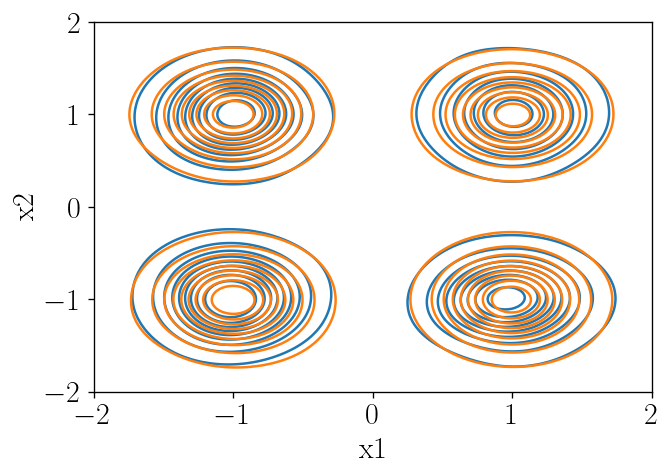

In [13]:
samples['x1'] = samples['x1'].flatten()
samples['x2'] = samples['x2'].flatten()
sns.kdeplot(data=samples, x='x1', y='x2')

samples_truth = gm.sample(10000, seed=rng_key)

samples_truth_dict = {}
samples_truth_dict['x1'] = samples_truth[:, 0]
samples_truth_dict['x2'] = samples_truth[:, 1]
sns.kdeplot(data=samples_truth_dict, x='x1', y='x2', ls='--')

plt.xlim(-2, 2)
plt.ylim(-2, 2)

In [70]:
from numpyro.contrib.einstein import RBFKernel, SteinVI, RandomFeatureKernel
from numpyro.infer import Predictive, Trace_ELBO, init_to_uniform
from numpyro.infer.autoguide import AutoDelta
from numpyro.optim import Adagrad, Adam
from functools import partial

In [81]:
stein = SteinVI(
    model,
    AutoDelta(model, init_loc_fn=partial(init_to_uniform, radius=1.)),
    Adagrad(0.1),
    Trace_ELBO(10),
    RBFKernel(),
    repulsion_temperature=1.,
    num_particles=100,
)

In [82]:
result = stein.run(
    rng_key,
    10000,
    progress_bar=True,
)

100%|████████████████████████████████████| 10000/10000 [00:27<00:00, 368.06it/s]


In [83]:
samples = stein.guide.sample_posterior(rng_key=rng_key, params=stein.get_params(result.state), sample_shape=(10000,))

<AxesSubplot: xlabel='x1', ylabel='x2'>

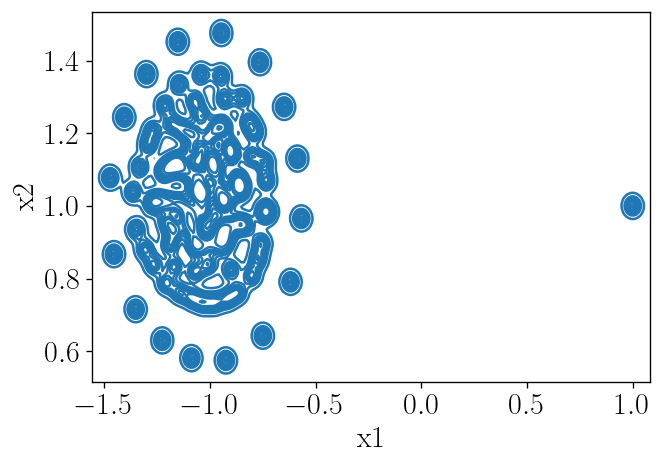

In [84]:
samples['x1'] = samples['x1'].flatten()
samples['x2'] = samples['x2'].flatten()
sns.kdeplot(data=samples, x='x1', y='x2')

# samples_truth = gm.sample(10000, seed=rng_key)

# samples_truth_dict = {}
# samples_truth_dict['x1'] = samples_truth[:, 0]
# samples_truth_dict['x2'] = samples_truth[:, 1]
# sns.kdeplot(data=samples_truth_dict, x='x1', y='x2', ls='--')

# plt.xlim(-2, 2)
# plt.ylim(-2, 2)